<a href="https://colab.research.google.com/github/kalina-tech/exploratory-analysis-pythonn/blob/main/E_Commerce_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Link to dashboard
https://public.tableau.com/app/profile/illia.kalinchuk/viz/E-CommerceAnalysis_17890397605820/Salesandgeographyoverview?publish=yes



In [5]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

auth.authenticate_user()
project_id = 'my-portfolio-project-507918'
dataset_name = 'DA'

client = bigquery.Client(project=project_id)


query = f"""
WITH base_sessions AS (
    SELECT
        s.date AS session_date,
        s.ga_session_id AS session_id,
        sp.continent,
        sp.country,
        sp.device,
        sp.browser,
        sp.mobile_model_name AS device_model,
        sp.operating_system,
        sp.language AS browser_language,
        sp.name AS traffic_source,
        sp.medium AS traffic_medium
    FROM
        `data-analytics-mate.{dataset_name}.session` AS s
    LEFT JOIN
        `data-analytics-mate.{dataset_name}.session_params` AS sp ON s.ga_session_id = sp.ga_session_id
),
session_accounts AS (
    SELECT
        acc_s.ga_session_id,
        a.id AS account_id,
        a.is_verified AS is_email_confirmed,
        a.is_unsubscribed
    FROM
        `data-analytics-mate.{dataset_name}.account_session` AS acc_s
    LEFT JOIN
        `data-analytics-mate.{dataset_name}.account` AS a ON acc_s.account_id = a.id
),
session_products AS (
    SELECT
        o.ga_session_id,
        p.category AS product_category,
        p.name AS product_name,
        p.price,
        p.short_description
    FROM
        `data-analytics-mate.{dataset_name}.order` AS o
    LEFT JOIN
        `data-analytics-mate.{dataset_name}.product` AS p ON o.item_id = p.item_id
)

SELECT
    bs.*,
    sa.account_id,
    sa.is_email_confirmed,
    sa.is_unsubscribed,
    sprod.product_category,
    sprod.product_name,
    sprod.price,
    sprod.short_description
FROM
    base_sessions AS bs
LEFT JOIN
    session_accounts AS sa ON bs.session_id = sa.ga_session_id
LEFT JOIN
    session_products AS sprod ON bs.session_id = sprod.ga_session_id
"""

df = client.query(query).to_dataframe(create_bqstorage_client=False)


df.to_csv('session_product_dataset.csv', index=False, encoding='utf-8')



Датасет успішно збережено у файл 'session_product_dataset.csv'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
print(
    f"Number of columns: {len(df.columns)}"
    f"\nNumeric columns: {df.select_dtypes(include='number').columns.tolist()}"
    f"\nNumber of numeric columns: {len(df.select_dtypes(include='number').columns.tolist())}"
    f"\nCategorical columns: {df.select_dtypes(include=['object', 'category']).columns.tolist()}"
    f"\nNumber of categorical columns: {len(df.select_dtypes(include=['object', 'category']).columns.tolist())}"
    f"\nNumber of datetime columns: {len(df.select_dtypes(include=[np.datetime64, 'datetime', 'datetime64[ns]']).columns.tolist())}"
    f"\nNumber of unique sessions: {df['session_id'].nunique()}"
    f"\nTime period: from {pd.to_datetime(df['session_date']).min().strftime('%Y-%m-%d')} to {pd.to_datetime(df['session_date']).max().strftime('%Y-%m-%d')}"
    f"\nAre there missing values: {df.isnull().any().any()}",
    f"\nNumber of duplicate rows: {df.duplicated().sum()}")
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print(f"\nColumns with missing values:\n{missing_data}")



Number of columns: 18
Numeric columns: ['session_id', 'account_id', 'is_email_confirmed', 'is_unsubscribed', 'price']
Number of numeric columns: 5
Categorical columns: ['continent', 'country', 'device', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_medium', 'product_category', 'product_name', 'short_description']
Number of categorical columns: 12
Number of datetime columns: 0
Number of unique sessions: 349545
Time period: from 2020-11-01 to 2021-01-31
Are there missing values: True 
Number of duplicate rows: 0

Columns with missing values:
account_id            321600
is_email_confirmed    321600
is_unsubscribed       321600
product_category      316007
price                 316007
product_name          316007
short_description     316007
browser_language      114266
dtype: int64


In [8]:
max_revenue_continent = df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3)
max_revenue_country = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5)

max_orders_continent = df.groupby('continent')['session_id'].nunique().sort_values(ascending=False).head(3)
max_orders_country = df.groupby('country')['session_id'].nunique().sort_values(ascending=False).head(5)

print("Top-3 continents by sales:\n", max_revenue_continent)
print("\nTop-5 countries by sales:\n", max_revenue_country)
print("\nTop-3 continents by unique sessions:\n", max_orders_continent)
print("\nTop-5 countries by unique sessions:\n", max_orders_country)

Top-3 continents by sales:
 continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64

Top-5 countries by sales:
 country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64

Top-3 continents by unique orders:
 continent
Americas    193179
Asia         83113
Europe       65135
Name: session_id, dtype: int64

Top-5 countries by unique orders:
 country
United States     153470
India              32763
Canada             25994
United Kingdom     11003
France              6958
Name: session_id, dtype: int64


Top-10 products by sales:
 product_category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64


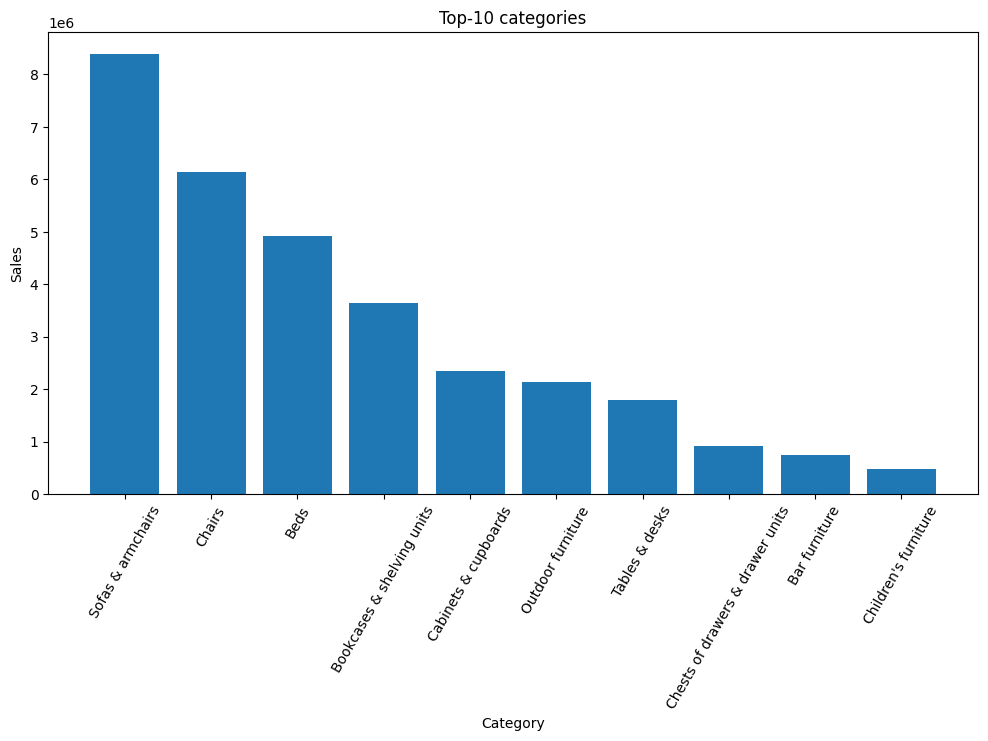

In [9]:
max_revenue_category = df.groupby('product_category')['price'].sum().sort_values(ascending=False).head(10)

print("Top-10 products by sales:\n", max_revenue_category)

plt.figure(figsize=(12, 6))
plt.bar(max_revenue_category.index, max_revenue_category.values)
plt.title("Top-10 categories")
plt.xlabel("Category")
plt.xticks(rotation=60)
plt.ylabel("Sales")
plt.show()

Top-10 categories by sales in the leading country (United States):

product_category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64


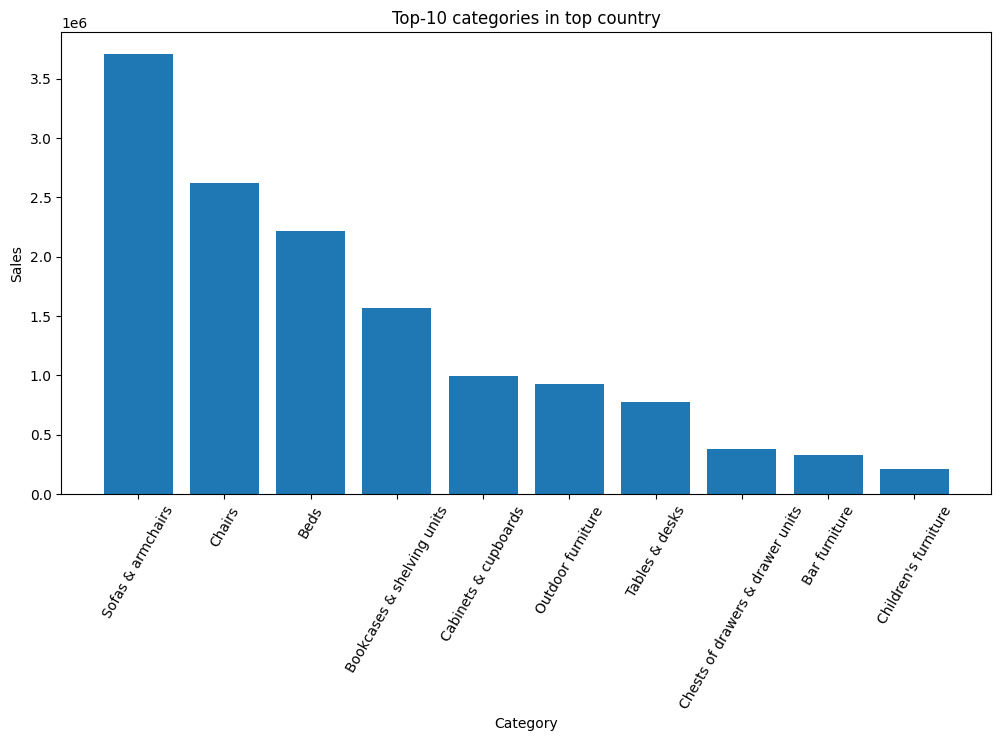

In [10]:
top_country_name = df.groupby('country')['price'].sum().sort_values(ascending=False).index[0]
top_categories_in_top_country = df[df['country'] == top_country_name].groupby('product_category')['price'].sum().sort_values(ascending=False).head(10)

print(f"Top-10 categories by sales in the leading country ({top_country_name}):\n")
print(top_categories_in_top_country)

plt.figure(figsize=(12, 6))
plt.bar(top_categories_in_top_country.index, top_categories_in_top_country.values)
plt.title("Top-10 categories in top country")
plt.xlabel("Category")
plt.xticks(rotation=60)
plt.ylabel("Sales")
plt.show()

In [11]:
total_sum = df['price'].sum()

total_device = df.groupby('device')['price'].sum()
total_device_percent = total_device/total_sum * 100

total_device_model = df.groupby('device_model')['price'].sum()
total_device_model_percent = total_device_model/total_sum * 100

print(f"Revenue by device in %: \n{total_device_percent}")
print(f"Revenue by device model in %: \n{total_device_model_percent}")

Revenue by device in %: 
device
desktop    59.002245
mobile     38.734924
tablet      2.262831
Name: price, dtype: float64
Revenue by device model in %: 
device_model
<Other>       20.440966
Chrome        27.835602
ChromeBook     5.725241
Edge           2.180746
Firefox        1.316998
Pixel 3        0.341390
Pixel 4 XL     0.369976
Safari        20.302504
iPad           1.403910
iPhone        20.082667
Name: price, dtype: float64


Revenue by traffic source in %: 
traffic_source
(data deleted)     6.262836
(direct)          23.442345
(organic)         34.202840
(referral)        17.646386
<Other>           18.445594
Name: price, dtype: float64


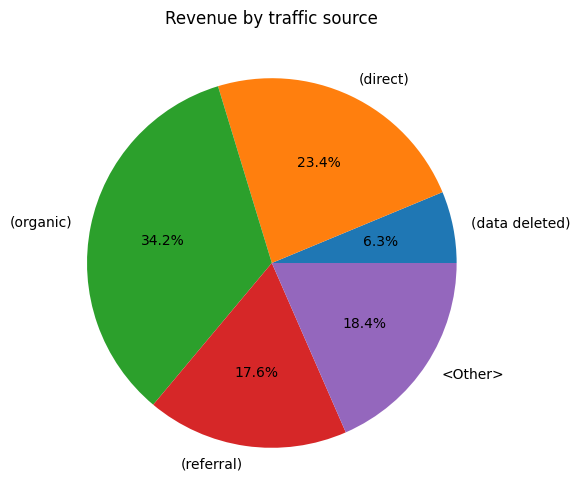

In [12]:
total_traffic_source = df.groupby('traffic_source')['price'].sum()
total_traffic_source_percent = total_traffic_source/total_sum * 100

print(f"Revenue by traffic source in %: \n{total_traffic_source_percent}")

plt.figure(figsize=(12, 6))
plt.pie(total_traffic_source_percent, labels=total_traffic_source_percent.index,autopct='%1.1f%%')
plt.title("Revenue by traffic source")
plt.show()

Percent of confirmed emails among registered users: 71.70%


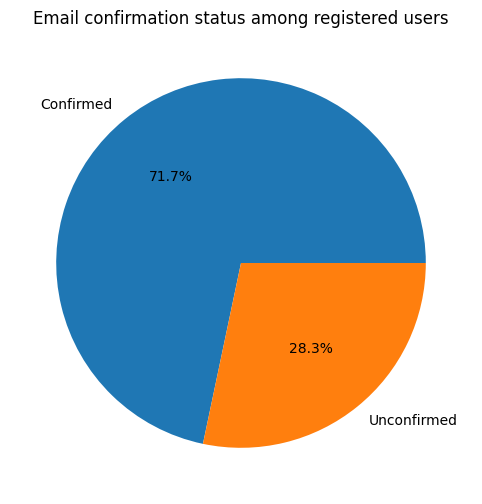

In [13]:
registered_df = df.dropna(subset=['account_id'])
total_registered = registered_df.shape[0]

is_confirmed = (registered_df['is_email_confirmed'] == True).sum()
is_unconfirmed = total_registered - is_confirmed

is_confirmed_percent = (is_confirmed / total_registered) * 100
print(f"Percent of confirmed emails among registered users: {is_confirmed_percent:.2f}%")

email_status_counts = pd.Series({
    'Confirmed': is_confirmed,
    'Unconfirmed': is_unconfirmed
})

plt.figure(figsize=(8, 6))
plt.pie(email_status_counts, labels=email_status_counts.index, autopct='%1.1f%%')
plt.title("Email сonfirmation status among registered users")
plt.show()

In [14]:
registered_df = df.dropna(subset=['account_id'])
is_unsubscribed = (registered_df['is_unsubscribed'] == True).sum()
total_registered = registered_df.shape[0]

is_unsubscribed_percent = (is_unsubscribed / total_registered) * 100

print(f"Percent of unsubsribed among registered users: {is_unsubscribed_percent}")

Percent of unsubsribed among registered users: 16.94399713723385


In [15]:
registered_df = df.dropna(subset=['account_id']).copy()

registered_df['is_unsubscribed_bool'] = registered_df['is_unsubscribed'].astype(bool)


behavior_analysis = registered_df.groupby('is_unsubscribed_bool')['price'].agg(
    total_sales='sum',
    order_count='count',
    avg_order_value='mean'
).reset_index()


behavior_analysis['subscription_status'] = behavior_analysis['is_unsubscribed_bool'].map({
    True: 'Unsubscribed',
    False: 'Subscribed'
})

print("Sales behavior comparison between subscribed and unsubscribed users:\n")
print(behavior_analysis[['subscription_status', 'total_sales', 'order_count', 'avg_order_value']])

Sales behavior comparison between subscribed and unsubscribed users:

  subscription_status  total_sales  order_count  avg_order_value
0          Subscribed    2150796.9         2334       921.506812
1        Unsubscribed     431721.6          447       965.820134


In [16]:
is_registered_country = registered_df.groupby('country')['account_id'].nunique().sort_values(ascending=False).head(10)

print(f"Top-10 countries with registered users:\n{is_registered_country}")

Top-10 countries with registered users:
country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Spain               536
Taiwan              500
China               490
Germany             490
Italy               386
Name: account_id, dtype: int64


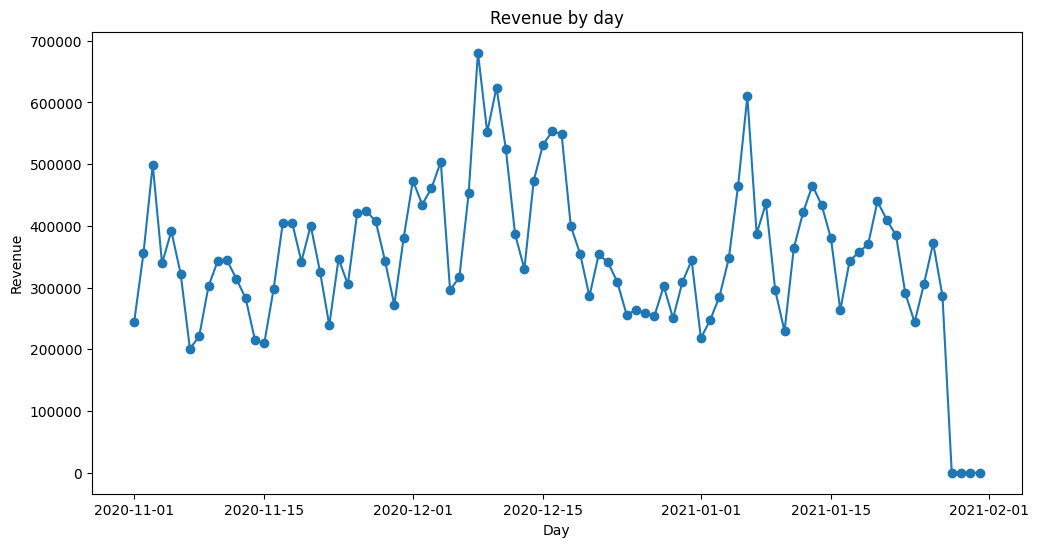

In [17]:
revenue_by_day = df.groupby('session_date')['price'].sum().reset_index()


plt.figure(figsize=(12, 6))
plt.plot(revenue_by_day['session_date'], revenue_by_day['price'], marker='o')

plt.title('Revenue by day')
plt.xlabel('Day')
plt.ylabel('Revenue')

plt.show()

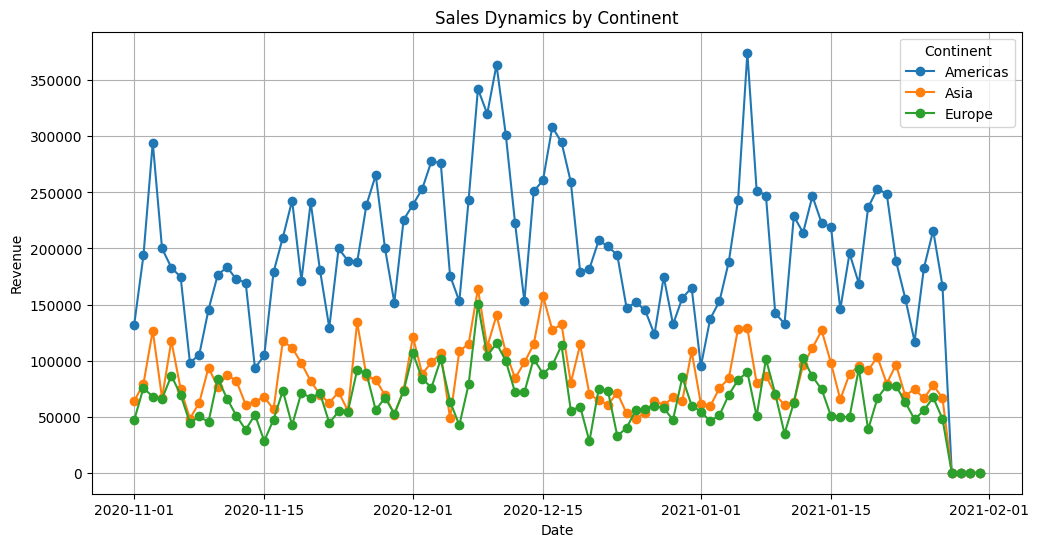

In [18]:
target_continents = ['Americas', 'Asia', 'Europe']
filtered_df = df[df['continent'].isin(target_continents)]

sales_by_continent = filtered_df.groupby(['session_date', 'continent'])['price'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for continent in sales_by_continent.columns:
    plt.plot(sales_by_continent.index, sales_by_continent[continent], label=continent, marker='o')

plt.title('Sales Dynamics by Continent')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend(title='Continent')
plt.grid(True)

plt.show()

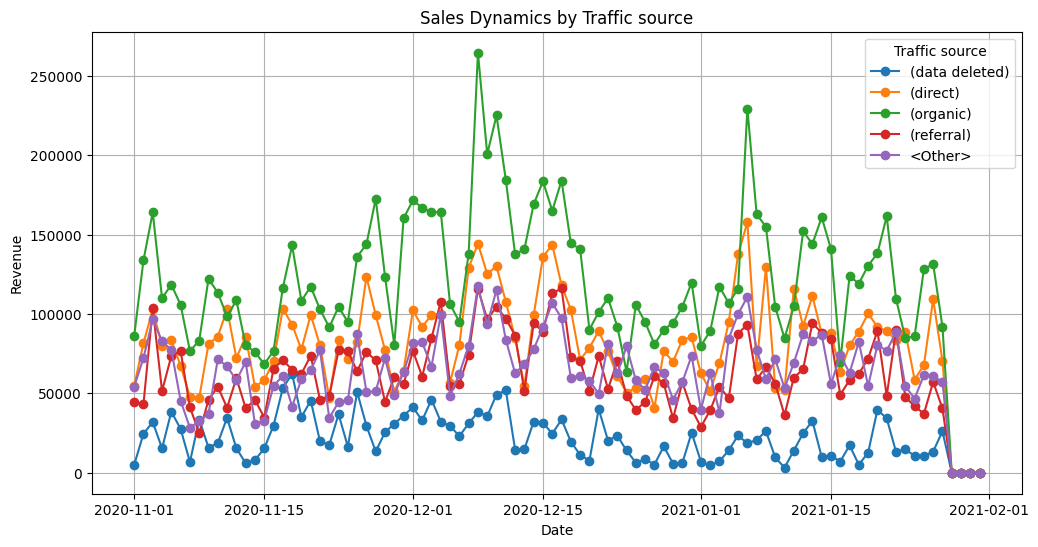

In [19]:
sales_by_traffic_source = df.groupby(['session_date', 'traffic_source'])['price'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for source in sales_by_traffic_source.columns:
    plt.plot(sales_by_traffic_source.index, sales_by_traffic_source[source], label=source, marker='o')

plt.title('Sales Dynamics by Traffic source')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend(title='Traffic source')
plt.grid(True)

plt.show()

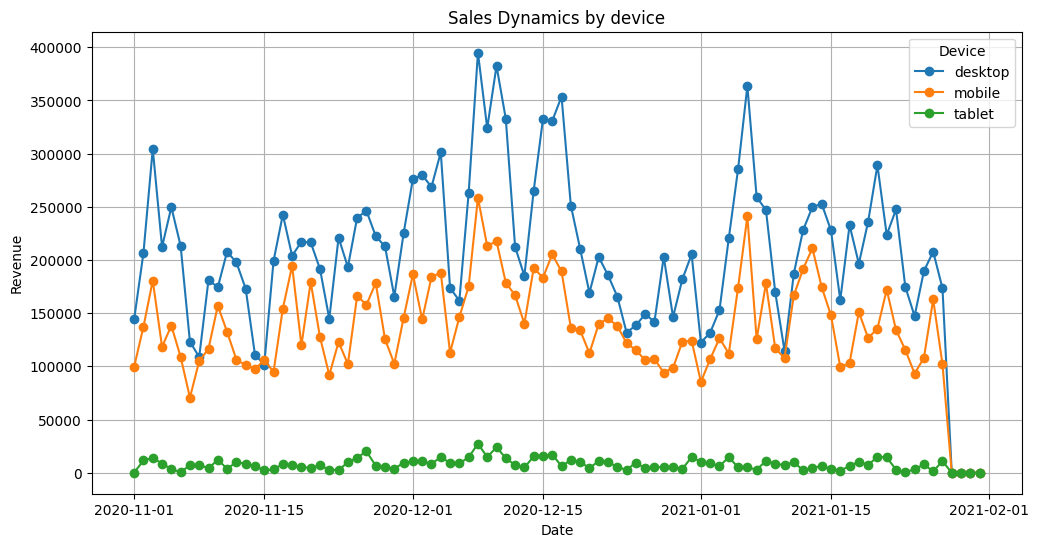

In [20]:
sales_by_device = df.groupby(['session_date', 'device'])['price'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for device in sales_by_device.columns:
    plt.plot(sales_by_device.index, sales_by_device[device], label=device, marker='o')

plt.title('Sales Dynamics by device')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend(title='Device')
plt.grid(True)

plt.show()

In [21]:
df_filtered = df[df['traffic_source'].notna() & df['device'].notna()]

summary_pivot = df_filtered.pivot_table(
    index='traffic_source',
    columns='device',
    values='session_id',
    aggfunc='nunique')

print(summary_pivot)

device          desktop  mobile  tablet
traffic_source                         
(data deleted)    12497    8448     469
(direct)          47825   31745    1812
(organic)         69431   46934    2659
(referral)        35890   24183    1363
<Other>           38786   25957    1546


In [22]:
top_countries = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5).index
top_categories = df.groupby('product_category')['price'].sum().sort_values(ascending=False).head(10).index
df_filtered_2 = df[df['country'].isin(top_countries) & df['product_category'].isin(top_categories)]


summary_pivot_2 = df_filtered_2.pivot_table(
    index='product_category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0
)

print(summary_pivot_2)

country                             Canada    France     India  \
product_category                                                 
Bar furniture                      51724.0   11199.0   57657.0   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Chairs                            417740.8  134029.4  544309.2   
Chests of drawers & drawer units   71952.0   21544.5   73111.0   
Children's furniture               30264.0   14258.0   39177.0   
Outdoor furniture                 185322.8   40486.4  162289.4   
Sofas & armchairs                 692427.5  187735.0  788430.0   
Tables & desks                    132678.0   42299.0  186157.5   

country                           United Kingdom  United States  
product_category                                                 
Bar furniture                            22103.0       330805.0  
Beds     

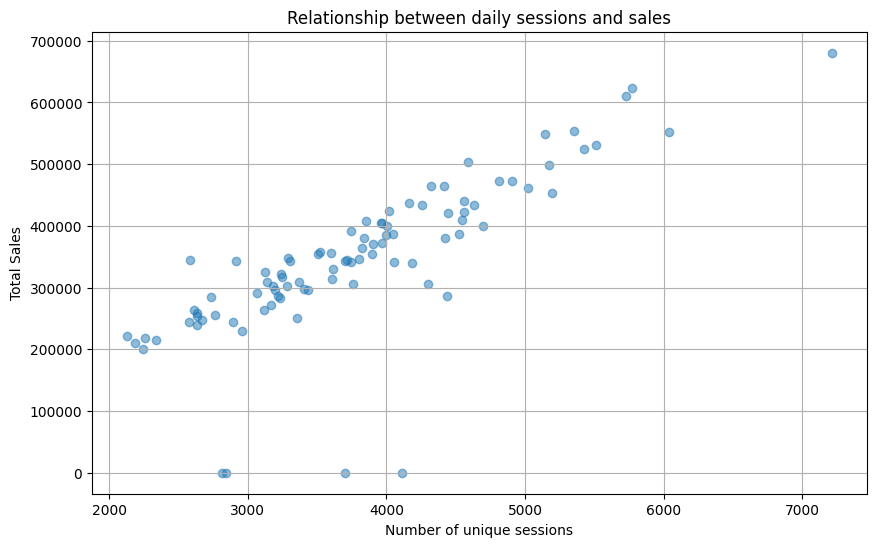

Pearson correlation coefficient: 0.7911
P-value: 6.483532312080735e-21


In [23]:
daily_stats = df.groupby('session_date').agg(
    sessions_count=('session_id', 'nunique'),
    total_sales=('price', 'sum')
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(daily_stats['sessions_count'], daily_stats['total_sales'], alpha=0.5)

plt.title('Relationship between daily sessions and sales')
plt.xlabel('Number of unique sessions')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

corr, p_value = stats.pearsonr(daily_stats['sessions_count'], daily_stats['total_sales'])

print(f"Pearson correlation coefficient: {corr:.4f}")
print(f"P-value: {p_value}")


In [24]:
top_1_continent= df.groupby('continent')['price'].sum().sort_values(ascending=False).index[0]
top_2_continent= df.groupby('continent')['price'].sum().sort_values(ascending=False).index[1]
top_3_continent= df.groupby('continent')['price'].sum().sort_values(ascending=False).index[2]


sales_by_period = df.groupby(['session_date', 'continent'])['price'].sum().unstack()
sales_top3 = sales_by_period[[top_1_continent, top_2_continent, top_3_continent]]

correlation = sales_top3.corr()
print(correlation)

for i, col1 in enumerate([top_1_continent, top_2_continent, top_3_continent]):
    for col2 in [top_1_continent, top_2_continent, top_3_continent][i+1:]:
        corr, p = stats.pearsonr(sales_top3[col1], sales_top3[col2])
        print(f"{col1} vs {col2}: r={corr}, p={p}")




continent  Americas      Asia    Europe
continent                              
Americas   1.000000  0.792025  0.770586
Asia       0.792025  1.000000  0.768427
Europe     0.770586  0.768427  1.000000
Americas vs Asia: r=0.7920245629479414, p=5.409189396197475e-21
Americas vs Europe: r=0.7705864582886499, p=2.6714492240629956e-19
Asia vs Europe: r=0.7684273823164164, p=3.8649460090531196e-19


In [25]:
sales_by_traffic = df.groupby(['session_date', 'traffic_source'])['price'].sum().unstack(fill_value=0)


correlation_matrix = sales_by_traffic.corr()
print(f"Correlation matrix: \n{correlation_matrix}")


columns = sales_by_traffic.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col1 = columns[i]
        col2 = columns[j]

        corr, p_value = stats.pearsonr(sales_by_traffic[col1], sales_by_traffic[col2])
        print(f"P-values: \n{col1} vs {col2}: r = {corr}, p-value = {p_value}")



Correlation matrix: 
traffic_source  (data deleted)  (direct)  (organic)  (referral)   <Other>
traffic_source                                                           
(data deleted)        1.000000  0.532887   0.560111    0.560018  0.422452
(direct)              0.532887  1.000000   0.820933    0.792201  0.764078
(organic)             0.560111  0.820933   1.000000    0.806062  0.775804
(referral)            0.560018  0.792201   0.806062    1.000000  0.747783
<Other>               0.422452  0.764078   0.775804    0.747783  1.000000
P-values: 
(data deleted) vs (direct): r = 0.532886705272532, p-value = 4.547104831175156e-08
P-values: 
(data deleted) vs (organic): r = 0.5601106108291954, p-value = 6.426904973339285e-09
P-values: 
(data deleted) vs (referral): r = 0.5600181328294165, p-value = 6.471705890645157e-09
P-values: 
(data deleted) vs <Other>: r = 0.4224519835252739, p-value = 2.7317181469393182e-05
P-values: 
(direct) vs (organic): r = 0.8209331619892235, p-value = 1.276326839

In [26]:
top_1_category= df.groupby('product_category')['price'].sum().sort_values(ascending=False).index[0]
top_2_category= df.groupby('product_category')['price'].sum().sort_values(ascending=False).index[1]
top_3_category= df.groupby('product_category')['price'].sum().sort_values(ascending=False).index[2]
top_4_category= df.groupby('product_category')['price'].sum().sort_values(ascending=False).index[3]
top_5_category= df.groupby('product_category')['price'].sum().sort_values(ascending=False).index[4]

sales_by_period_category = df.groupby(['session_date', 'product_category'])['price'].sum().unstack()
sales_top5 = sales_by_period_category[[top_1_category, top_2_category, top_3_category, top_4_category, top_5_category]]

correlation = sales_top5.corr()
print(f"Correlation matrix: \n{correlation}")

for i, col1 in enumerate([top_1_category, top_2_category, top_3_category, top_4_category, top_5_category]):
    for col2 in [top_1_category, top_2_category, top_3_category, top_4_category, top_5_category][i+1:]:
        corr, p = stats.pearsonr(sales_top5[col1], sales_top5[col2])
        print(f"P-values: \n{col1} vs {col2}: r={corr}, p={p}")




Correlation matrix: 
product_category            Sofas & armchairs    Chairs      Beds  \
product_category                                                    
Sofas & armchairs                    1.000000  0.578248  0.535378   
Chairs                               0.578248  1.000000  0.554500   
Beds                                 0.535378  0.554500  1.000000   
Bookcases & shelving units           0.666194  0.637090  0.592913   
Cabinets & cupboards                 0.657563  0.572870  0.514609   

product_category            Bookcases & shelving units  Cabinets & cupboards  
product_category                                                              
Sofas & armchairs                             0.666194              0.657563  
Chairs                                        0.637090              0.572870  
Beds                                          0.592913              0.514609  
Bookcases & shelving units                    1.000000              0.539428  
Cabinets & cupboards 

In [27]:
registered = df.dropna(subset=['account_id'])
unregistered = df[df['account_id'].isna()]


registered_sales = registered.groupby('session_date')['price'].sum()
unregistered_sales = unregistered.groupby('session_date')['price'].sum()


daily_comparison = pd.DataFrame({
    'registered': registered_sales,
    'unregistered': unregistered_sales
}).fillna(0)


shapiro_reg = stats.shapiro(daily_comparison['registered'])
shapiro_unreg = stats.shapiro(daily_comparison['unregistered'])

print("Shapiro-Wilk Test")
print(f"Registered p-value: {shapiro_reg.pvalue}")
print(f"Unregistered p-value: {shapiro_unreg.pvalue}\n")

print("Descriptive Statistics")
print(daily_comparison.describe())


if shapiro_reg.pvalue > 0.05 and shapiro_unreg.pvalue > 0.05:
    print("The samples have a normal distribution, so use Paired t-test:")
    stat, p_value = stats.ttest_rel(daily_comparison['registered'], daily_comparison['unregistered'])
else:
    print("The samples do NOT have a normal distribution, so use Wilcoxon signed-rank test:")
    stat, p_value = stats.wilcoxon(daily_comparison['registered'], daily_comparison['unregistered'])

print(f"Statistic: {stat}, p-value: {p_value}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference between the daily sales of registered and unregistered users")
else:
    print("\nConclusion: There is no statistically significant difference between the daily sales of registered and unregistered users")

Shapiro-Wilk Test
Registered p-value: 0.14816728286235686
Unregistered p-value: 0.0012184604855253293

Descriptive Statistics
         registered   unregistered
count     92.000000      92.000000
mean   28070.853261  319447.963043
std    12124.817697  113764.392969
min        0.000000       0.000000
25%    19938.250000  263005.700000
50%    27233.500000  315170.750000
75%    35478.600000  375010.750000
max    68151.100000  612358.400000
The samples do NOT have a normal distribution, so use Wilcoxon signed-rank test:
Statistic: 0.0, p-value: 3.732014234846569e-16

Conclusion: There is a statistically significant difference between the daily sales of registered and unregistered users


In [28]:
sessions_by_traffic = df.groupby(['session_date', 'traffic_source'])['session_id'].nunique().unstack(fill_value=0)
groups = [sessions_by_traffic[col].values for col in sessions_by_traffic.columns]
group_names = sessions_by_traffic.columns

print("Shapiro-Wilk Test")
is_normal = True
for name, group in zip(group_names, groups):
    stat_shapiro, p_val_shapiro = stats.shapiro(group)
    print(f"Traffic source '{name}': p-value = {p_val_shapiro}")
    if p_val_shapiro < 0.05:
        is_normal = False

print("\nStatistical Test")
if is_normal:
    print("All groups have a normal distribution. Using ANOVA:")
    stat, p_value = stats.f_oneway(*groups)
    test_name = "ANOVA"
else:
    print("At least one group does NOT have a normal distribution. Using Kruskal-Wallis test:")
    stat, p_value = stats.kruskal(*groups)
    test_name = "Kruskal-Wallis"

print(f"{test_name} Statistic: {stat}, p-value: {p_value}")


if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in daily sessions between different traffic sources.")
else:
    print("\nConclusion: There is no statistically significant difference in daily sessions between traffic sources.")

Shapiro-Wilk Test
Traffic source '(data deleted)': p-value = 0.06300339931956317
Traffic source '(direct)': p-value = 0.034278771626201326
Traffic source '(organic)': p-value = 0.020078849258587533
Traffic source '(referral)': p-value = 0.04545858359764536
Traffic source '<Other>': p-value = 0.004477316445943932

Statistical Test
At least one group does NOT have a normal distribution. Using Kruskal-Wallis test:
Kruskal-Wallis Statistic: 339.7419293574746, p-value: 2.8750518129035357e-72

Conclusion: There is a statistically significant difference in daily sessions between different traffic sources.


In [29]:
total_sessions_europe = df[df['continent'] == 'Europe']['session_id'].nunique()
total_sessions_america = df[df['continent'] == 'Americas']['session_id'].nunique()

organic_europe = df[(df['continent'] == 'Europe') & (df['traffic_source'] == '(organic)')]['session_id'].nunique()
organic_america = df[(df['continent'] == 'Americas') & (df['traffic_source'] == '(organic)')]['session_id'].nunique()

z_stat, p_value = sm.stats.proportions_ztest([organic_europe, organic_america], [total_sessions_europe, total_sessions_america])

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")


if p_value < 0.05:
    print("There is a statistically significant difference between Europe and Americas")
else:
    print("No statistically significant difference between Europe and Americas")

Z-statistic: 0.06907726418476848
P-value: 0.9449281183430579
No statistically significant difference between Europe and Americas


# E-Commerce sales, traffic, and user behavior analysis

## 1. Data Understanding and Content
Within the project scope, a comprehensive dataset describing the e-commerce platform's operational activities and user behavior was processed and analyzed.

The data was extracted from Google BigQuery (`DA` dataset) using a complex SQL query that joined three main logical areas:
* **Session Data:** Contains session dates, device types, browsers, continents, countries, and traffic sources (`session` and `session_params` tables).
* **Account Data:** Contains information about registered users, email confirmation status, and newsletter subscriptions (`account_session` and `account` tables).
* **Transaction Data:** Contains product categories, product names, and pricing for items purchased during the sessions (`order` and `product` tables).

### Key Connection Fields:
The tables were joined into a single flat relational structure using `ga_session_id` (to connect sessions with accounts and orders) and `item_id` (to connect orders with product details).

## 2. Data Cleaning and Handling Missing Values
The following steps and observations were made during the data preprocessing stage:

The dataset consists of **349,545** unique sessions spanning from **2020-11-01** to **2021-01-31**.

Missing values were primarily identified in account-related fields (`account_id`, `is_email_confirmed`, etc.) with ~321,600 missing rows. This is a natural occurrence, as these represent unregistered users (guest checkouts or visitors who didn't create an account). These rows were retained to analyze guest behavior. Missing product details (~316,007 rows) represent sessions where no purchase was made.

### Key Metrics After Cleaning:
* Total number of unique sessions: **349,545**
* Time period: **3 months** (Nov 2020 - Jan 2021)
* Email confirmation rate among registered users: **71.7%**
* Unsubscribe rate among registered users: **16.9%**

## 3. Product Category Analysis
The analysis of sales by product category revealed absolute leaders in financial indicators:
* The highest volumes of sales belong to the furniture categories, specifically **Sofas & armchairs, Chairs, and Beds**.
* This trend remains consistent in the top-performing country (the United States), where "Sofas & armchairs" strictly dominate the sales volume.
* Categories with smaller volumes (like Children's furniture or Bar furniture) demonstrate a significantly lower share in overall revenue.

## 4. Geographic Distribution
Key sales markets were explored using aggregation and grouping:
* The absolute leader by continent is the **Americas** (with over $17.6M in sales and 193k unique sessions), followed by Asia and Europe.
* On a country level, the **United States** brings the highest financial result to the company by a massive margin (~$13.9M), followed by **India, Canada, the United Kingdom, and France**. This allows for a clear understanding of where the core customer base is located.

## 5. Device and Platform Usage
A comparison of devices and browsers used by customers showed clear preferences:
* **Desktop** users generate the majority of the revenue (**~59.0%**), but **Mobile** users account for a very significant portion (**~38.7%**).
* Among browsers and device models, **Chrome** leads with **~27.8%**, followed closely by **Safari (~20.3%)** and **iPhone (~20.0%)**. This indicates a diverse user base split heavily between Google and Apple ecosystems.

## 6. Traffic Sources & User Behavior (Statistical Analysis)
The study of traffic channels and user registration status revealed the following:
* **Organic** traffic is the main driver of revenue (**~34.2%**), followed by **Direct (~23.4%)** and **Referral (~17.6%)**.
* A statistical test (Kruskal-Wallis / ANOVA) confirmed that there are **statistically significant differences** in the number of daily sessions driven by different traffic sources.
* A statistical test (Wilcoxon signed-rank test / Paired t-test) proved a **statistically significant difference** between the daily sales of registered and unregistered users, highlighting the financial impact of user accounts.

## 7. Conclusions and Recommendations
* **Focus on the US Market:** Since the United States is the primary driver of both sessions and revenue, marketing budgets should heavily target this region, while testing localized strategies in emerging top countries like India and Canada.
* **Boost User Registration:** Statistical analysis proves that registered user behavior differs significantly from guests. The company should implement incentives (e.g., sign-up discounts, loyalty programs) to encourage guest visitors to create accounts, as 71.7% of them successfully confirm their emails.
* **Optimize Top Categories:** The company must ensure consistent inventory availability for "Sofas & armchairs" and "Chairs." Marketing efforts should highlight these products through targeted ads and homepage features.
* **Mobile & Desktop Optimization:** With Desktop bringing 59% of revenue and Mobile nearly 39%, the UI/UX must remain flawless on both platforms. Special attention should be paid to optimizing the website for iPhone and Safari users.
* **Leverage Organic Traffic:** Since Organic traffic brings the most revenue, the company should maintain strong SEO practices and investigate the strategies used in the Referral channel to scale its performance further.